<a href="https://colab.research.google.com/github/Evelyn-Rojas/Simulacion-ll/blob/main/ProyectoParadoja.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<font color= "mediumslateblue">**Martínez Cornejo Vanessa**

<font color= "mediumslateblue">**Hernádez Cortés Efraín**

<font color= "mediumslateblue">**Reyes López Gonzalo Roberto**

<font color= "mediumslateblue">**Rojas Roa Evelyn Tania**

---


# <font color= 'lightseagreen'> **PARADOJA DE CUMPLEAÑOS**

---



**Resolución Analítica**

Se desea calcular la probabilidad de que, en un grupo de $n$ personas, al menos dos compartan el mismo cumpleaños.

Utilizando el complemento:

$$
P(\text{al menos una coincidencia}) = 1 - P(\text{todos diferentes})
$$


Para obtener la probabilidad de todas las diferentes, supondremos 365 días, equiprobabilidad e independencia:

$$
P(\text{todos diferentes}) = \frac{365}{365} \cdot \frac{364}{365} \cdot \frac{363}{365} \cdots \frac{365 - n + 1}{365}
$$

donde, podemos verla como

$$
P(\text{todos diferentes}) = \prod_{k=0}^{n-1} \left(1 - \frac{k}{365}\right)
$$

O bien

$$
P(\text{todos diferentes}) = \frac{365!}{(365 - n)! \cdot 365^n}
$$

Aplicando logaritmo para convertir el producto en una suma, obtenemos

$$
\ln P = \sum_{k=0}^{n-1} \ln\left(1 - \frac{k}{365}\right) ....(1)
$$
Utilizando una aproximación obtenida apartir de series de Taylor, se tendrá que para valores pequeños de $x$:

$$
\ln(1 - x) \approx -x
$$

Entonces:

$$
\ln\left(1 - \frac{k}{365}\right) \approx -\frac{k}{365}
$$

Sustituimos en (1)

$$
\ln P \approx -\sum_{k=0}^{n-1} \frac{k}{365}
$$

$$
\ln P \approx -\frac{1}{365} \sum_{k=0}^{n-1} k
$$

Sumatoria conocida

$$
\sum_{k=0}^{n-1} k = \frac{n(n-1)}{2}
$$

Entonces

$$
\ln P \approx -\frac{n(n-1)}{2 \cdot 365}
$$

Aplicamos la exponencial para eliminar el logaritmo

$$
P(\text{todos diferentes}) \approx e^{-\frac{n(n-1)}{2 \cdot 365}}
$$

Sustituyendo en la probabilidad de coincidencia

$$
P(\text{coincidencia}) \approx 1 - e^{-\frac{n(n-1)}{2 \cdot 365}}
$$

* **Ejemplo:**

Para $n = 23$:

$$
P(\text{coincidencia}) \approx 0.507
$$

<font color="mediumaquamarine">> **Caso 1:**

In [17]:
import random
def simular_cumpleaños(n_personas, n_simulaciones):
    exitos = 0
    for i in range(n_simulaciones):
        cumpleaños = []  # lista para guardar cumpleaños
        # Generar n cumpleaños aleatorios
        for j in range(n_personas):
            cumpleaños.append(random.randint(1, 365))
        # Buscar si hay repetidos
        if len(set(cumpleaños)) < n_personas:
            exitos += 1
    return exitos / n_simulaciones
# Ejemplo para el salón de clases (n=23)
n = 23
n2 = 10**5
prob = simular_cumpleaños(n, n2)
print(f"Probabilidad con {n} personas: {prob:.4f}")

Probabilidad con 23 personas: 0.5101


<font color="mediumaquamarine">> **Caso 2:**

Consideraciones a tomar:

* Años bisiestos
* Distinta probabilidad de nacimientos.


Para obtener las probabilidades de nacimientos dependiendo el mes se utilizara una base de datos de los nacimientos en Estados Unidos desde el año 2000-2014.

In [18]:
import pandas as pd
import numpy as np

df = pd.read_csv('US_births_2000-2014_SSA.csv')
# Agrupamos por mes y día para obtener el total de nacimientos históricos por fecha
# Esto promedia los años bisiestos y normales automáticamente
df_agrupado = df.groupby(['month', 'date_of_month'])['births'].sum().reset_index()
# Creamos una columna de "ID de día" (un identificador único para cada fecha del año)
df_agrupado['day_id'] = range(len(df_agrupado))
# Calculamos los pesos (probabilidades relativas)
pesos_reales = df_agrupado['births'].values
dias_posibles = df_agrupado['day_id'].values

In [19]:
#Simulación
def simulacion_cumpleaños(n_personas, iteraciones):
    exitos = 0
    for i in range(iteraciones):
        # Generar n cumpleaños basados en las probabilidades históricas
        grupo = np.random.choice(dias_posibles, size=n_personas, p=pesos_reales/pesos_reales.sum())
        #Coincidencias
        if len(np.unique(grupo)) < n_personas:
            exitos += 1
    return (exitos / iteraciones)

#Resultados
n = 23
iteraciones=10**5
prob_real = simulacion_cumpleaños(n,iteraciones)

print(f"Para un grupo de {n} personas")
print(f"Probabilidad de coincidencia: {prob_real:.4f}")

Para un grupo de 23 personas
Probabilidad de coincidencia: 0.5090


Diferencia entre ambos resultados obtenidos:

In [20]:
Diferencia= prob_real-prob
Diferencia

-0.0011099999999999444

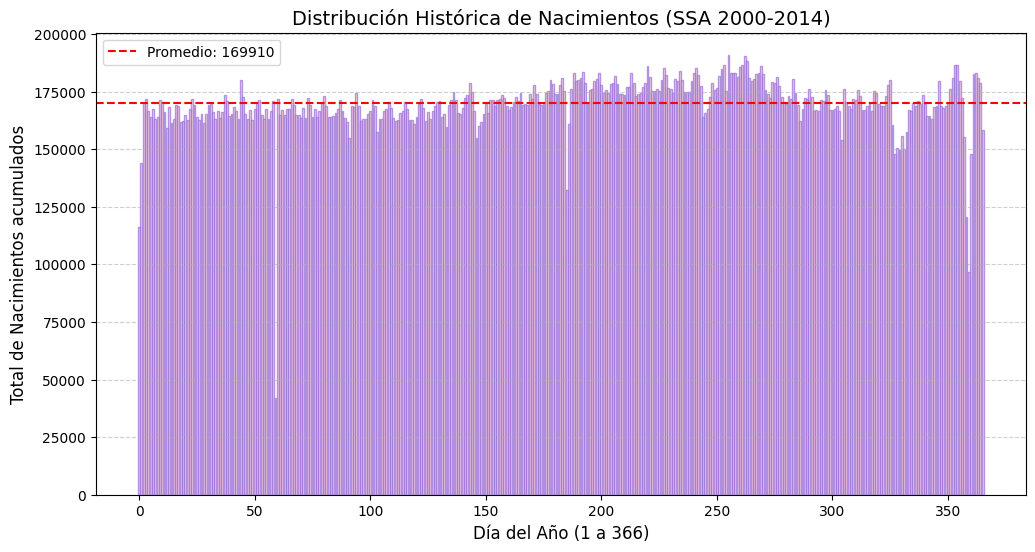

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
def graficar_distribucion_nacimientos(df_agrupado):
    plt.figure(figsize=(12, 6))
    plt.bar(df_agrupado['day_id'], df_agrupado['births'], color='pink', edgecolor='mediumpurple', alpha=0.7)
    # Aproximadamente cada 30 días cambia el mes
    plt.title('Distribución Histórica de Nacimientos (SSA 2000-2014)', fontsize=14)
    plt.xlabel('Día del Año (1 a 366)', fontsize=12)
    plt.ylabel('Total de Nacimientos acumulados', fontsize=12)
    # Añadir una línea promedio para ver las desviaciones
    promedio = df_agrupado['births'].mean()
    plt.axhline(promedio, color='red', linestyle='--', label=f'Promedio: {promedio:.0f}')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.show()

graficar_distribucion_nacimientos(df_agrupado)

**¿Cambia mucho el resultado con supuestos clásicos al más exacto?**

No, el resultado no cambia de forma drástica, pero sí aumenta ligeramente.

Al comparar los supuestos clásicos con los datos exactos (SSA), se confirma que la realidad siempre aumenta la probabilidad de coincidencia. Cualquier desviación de la uniformidad (como el pico de nacimientos en septiembre) actúa como un "imán" estadístico que amontona los eventos, haciendo que las colisiones sean más frecuentes de lo que dicta la teoría.

---



### <font color= 'lightseagreen'> **Aplicaciones**



####<font color="mediumpurple">**Criptografía**

Una de las aplicaciones más importantes de la paradoja del cumpleaños se encuentra en el análisis de seguridad de funciones hash criptográficas.

**Funciones hash**

Una función hash transforma un mensaje de cualquier tamaño en una salida de longitud fija. Formalmente:

$$
h: \{0,1\}^* \rightarrow \{0,1\}^m
$$

donde $m$ es el número de bits del hash.

Estas funciones se utilizan en seguridad informática para almacenar contraseñas, firmas digitales y verificación de integridad.

**Problema de colisiones**

Una colisión ocurre cuando dos entradas distintas producen el mismo hash:

$$
h(x_1) = h(x_2), \quad x_1 \neq x_2
$$

En teoría, encontrar una colisión debería requerir aproximadamente $2^m$ intentos, ya que existen $2^m$ posibles valores de salida.

Sin embargo, debido a la paradoja del cumpleaños, el número esperado de intentos para encontrar una colisión es mucho menor:

$$
n \approx \sqrt{2^m} = 2^{m/2}
$$

Esto se debe a que el número de comparaciones posibles entre $n$ hashes es:

$$
\binom{n}{2} = \frac{n(n-1)}{2}
$$

y las colisiones comienzan a aparecer cuando este valor es del orden del número total de posibles hashes.  Este crecimiento es cuadrático, lo que hace que las colisiones aparezcan mucho más rápido de lo esperado.

Esto tiene consecuencias importantes:

- Un hash de $m$ bits no ofrece seguridad de $2^m$, sino aproximadamente de $2^{m/2}$ frente a colisiones.
- Para garantizar seguridad adecuada, se requieren hashes más largos.

**Conclusión:**
La paradoja del cumpleaños muestra que las colisiones en funciones hash aparecen mucho antes de lo esperado, reduciendo significativamente la seguridad efectiva de los sistemas criptográficos. Por ello, el diseño de funciones hash debe considerar este fenómeno para evitar vulnerabilidades.
